# Project Kijkcijfers

## Data ophalen

In [3]:
import requests
import pandas as pd
from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor, as_completed
import time

### Cim API

Ik haal de kijkcijferdata van CIM op aan de hand van parallellisatie. De fetch_data functie haalt de data op. Waneer een entry faalt om opgehaald te worden, dus wanneer de statuscode niet 200 is, wordt er 1 seconde gewacht en nog 2 keer geprobeerd om de data op te halen. Nadien gebruik ik ThreadPoolExecutor om fetch_data te parallelliseren. Met 5 threads wordt de fetch_data functie constant voor 5 entries tegelijk uitgevoerd. Uiteindelijk steek ik de json data in een pandas dataframe en zet ik deze in een csv, zodat ik de data makkelijk kan herbruiken. Aanvankelijk probeerde ik zonder parallellisatie, maar dit duurde veel te lang. Aan de hand van Chat GPT heb ik parallellisatie gebruikt en dit werkte veel sneller en met een max threads van 5 verloor ik ook geen data.

In [ ]:

start_date = datetime(2016, 10, 1)
end_date = datetime.today()
# aantal threads vr paralellisatie
max_threads = 5

# Alle datums
date_list = [(start_date + timedelta(days=i)).strftime("%Y-%m-%d")
             for i in range((end_date - start_date).days + 1)]

def fetch_data(date_str):
    url = f"https://api.cim.be/api/cim_tv_public_results_daily_views?dateDiff={date_str}&reportType=north"
    retries = 3
    for attempt in range(retries):
        try:
            response = requests.get(url, timeout=10)
            if response.status_code == 200:
                print(f"{date_str}: Succes")
                # lijst van programmas anders lege lijst
                return response.json().get("hydra:member", [])
            else:
                print(f"{date_str}: Fout met status {response.status_code}")
                time.sleep(1)
        except Exception as e:
            print(f"⚠️ Fout op {date_str}: {e}")
            time.sleep(2)
    return []  # bij falen lege lijst

# parallelisatie
data = []
with ThreadPoolExecutor(max_workers=max_threads) as executor:
    futures = {executor.submit(fetch_data, date): date for date in date_list}
    for future in as_completed(futures):
        result = future.result()
        data.extend(result)

# data naar csv CSV
df = pd.json_normalize(data)
df.to_csv("kijkcijfers_cim.csv", index=False)
print("CSV opgeslagen!")


### Visualcrossing API

Voor weerdata gebruikte ik eerst visualcrossing aangezien deze API zowel historische data als forecast data heeft, nodig om voorspellingen in de toekomst te doen. In de url stel ik de locatie in op Gent, geef ik de start en eind datum mee voor de data die ik wel. Bij de parameters geef ik mijn api key mee, de eenheid voor de data en de features die ik wou ophalen.
Ik heb dit uiteindelijk niet gebruikt, aangezien ik door een fout mijn max aantal requests heb overschreden en mijn data over meer dan 4 dagen zou moeten ophalen.

In [8]:
api_key = "N4DFBZCVS628LHL8KCLF7ER62"
location = "Gent,Belgium"
start_date = datetime.strptime("2016-10-01", "%Y-%m-%d")
end_date = datetime.strptime("2025-05-30", "%Y-%m-%d")
#url = f"https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/{location}/{start_date}/{end_date}"

max_requests = 1000
current_start = start_date
totaal_data = []

while current_start <= end_date:
    current_end = min(current_start + timedelta(days=max_requests - 1), end_date)
    url = f"https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/{location}/{current_start.strftime('%Y-%m-%d')}/{current_end.strftime('%Y-%m-%d')}"

    params = {
        "key": api_key,
        "unitGroup": "metric",
        
        "elements" : "datetime,tempmax,tempmin,temp,precip,humidity,windspeed,cloudcover,sunrise,sunset",
        "contentType": "json"
    }

    response = requests.get(url, params)

    if response.status_code == 200:
        data = response.json()
        days = data.get('days', [])
        totaal_data.extend(days)
    else:
        print(f"Fout bij ophalen weerdata: {response.status_code}, {response.text}")
        break
    current_start = current_end + timedelta(days=1)

df = pd.DataFrame(totaal_data)
df.to_csv("weerdata_gent.csv", index=False)
print("Weerdata opgeslagen.")


Fout bij ophalen weerdata: 429, You have exceeded the maximum number of daily result records for your account. 
Weerdata succesvol opgeslagen.


In [9]:
pd.DataFrame(totaal_data).to_csv("weerdata_gent.csv", index=False)

### Open-meteo

Toen ik een nieuwe weer api zocht met zowel historische als forecast data kwam ik bij open-meteo terecht. Deze had een veel groter aantal max requests en hda bovendien een tool om een python script te maken om de data mee op te halen. Ik moest enkele features kiezen, mijn datums instellen en de coordinaten van Gent meegeven. Daarna kreeg ik volgend script.

In [ ]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 50.85045,
	"longitude": 4.34878,
	"start_date": "2016-10-01",
	"end_date": "2025-05-28",
	"daily": ["temperature_2m_max", "sunrise", "sunset", "daylight_duration", "precipitation_sum", "wind_speed_10m_max", "wind_gusts_10m_max", "sunshine_duration", "precipitation_hours", "cloud_cover_mean", "cloud_cover_max", "cloud_cover_min", "visibility_mean"],
	"timezone": "auto"
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation {response.Elevation()} m asl")
print(f"Timezone {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0 {response.UtcOffsetSeconds()} s")

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_max = daily.Variables(0).ValuesAsNumpy()
daily_sunrise = daily.Variables(1).ValuesInt64AsNumpy()
daily_sunset = daily.Variables(2).ValuesInt64AsNumpy()
daily_daylight_duration = daily.Variables(3).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(4).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(5).ValuesAsNumpy()
daily_wind_gusts_10m_max = daily.Variables(6).ValuesAsNumpy()
daily_sunshine_duration = daily.Variables(7).ValuesAsNumpy()
daily_precipitation_hours = daily.Variables(8).ValuesAsNumpy()
daily_cloud_cover_mean = daily.Variables(9).ValuesAsNumpy()
daily_cloud_cover_max = daily.Variables(10).ValuesAsNumpy()
daily_cloud_cover_min = daily.Variables(11).ValuesAsNumpy()
daily_visibility_mean = daily.Variables(12).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	end = pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["sunrise"] = daily_sunrise
daily_data["sunset"] = daily_sunset
daily_data["daylight_duration"] = daily_daylight_duration
daily_data["precipitation_sum"] = daily_precipitation_sum
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["wind_gusts_10m_max"] = daily_wind_gusts_10m_max
daily_data["sunshine_duration"] = daily_sunshine_duration
daily_data["precipitation_hours"] = daily_precipitation_hours
daily_data["cloud_cover_mean"] = daily_cloud_cover_mean
daily_data["cloud_cover_max"] = daily_cloud_cover_max
daily_data["cloud_cover_min"] = daily_cloud_cover_min
daily_data["visibility_mean"] = daily_visibility_mean

daily_dataframe = pd.DataFrame(data = daily_data)
daily_dataframe.head(10)

In [11]:
daily_dataframe.to_csv("weerdata_gent.csv", index=False)

Hieronder doe ik hetzelfde maar met forecast data voor de nieuwe input

In [377]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": 51.053581,
	"longitude": 3.722969,
	"daily": ["sunrise", "sunset", "temperature_2m_max", "daylight_duration", "precipitation_sum", "wind_speed_10m_max", "wind_gusts_10m_max", "sunshine_duration", "precipitation_hours", "cloud_cover_mean", "cloud_cover_max", "cloud_cover_min"],
	"timezone": "auto",
	"forecast_days": 16
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation {response.Elevation()} m asl")
print(f"Timezone {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0 {response.UtcOffsetSeconds()} s")

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_sunrise = daily.Variables(0).ValuesInt64AsNumpy()
daily_sunset = daily.Variables(1).ValuesInt64AsNumpy()
daily_temperature_2m_max = daily.Variables(2).ValuesAsNumpy()
daily_daylight_duration = daily.Variables(3).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(4).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(5).ValuesAsNumpy()
daily_wind_gusts_10m_max = daily.Variables(6).ValuesAsNumpy()
daily_sunshine_duration = daily.Variables(7).ValuesAsNumpy()
daily_precipitation_hours = daily.Variables(8).ValuesAsNumpy()
daily_cloud_cover_mean = daily.Variables(9).ValuesAsNumpy()
daily_cloud_cover_max = daily.Variables(10).ValuesAsNumpy()
daily_cloud_cover_min = daily.Variables(11).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	end = pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["sunrise"] = daily_sunrise
daily_data["sunset"] = daily_sunset
daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["daylight_duration"] = daily_daylight_duration
daily_data["precipitation_sum"] = daily_precipitation_sum
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["wind_gusts_10m_max"] = daily_wind_gusts_10m_max
daily_data["sunshine_duration"] = daily_sunshine_duration
daily_data["precipitation_hours"] = daily_precipitation_hours
daily_data["cloud_cover_mean"] = daily_cloud_cover_mean
daily_data["cloud_cover_max"] = daily_cloud_cover_max
daily_data["cloud_cover_min"] = daily_cloud_cover_min

forecast_dataframe = pd.DataFrame(data = daily_data)
forecast_dataframe.to_csv("forecast_gent.csv", index=False)

Coordinates 51.051998138427734°N 3.7119998931884766°E
Elevation 10.0 m asl
Timezone b'Europe/Brussels'b'GMT+2'
Timezone difference to GMT+0 7200 s


## Preprocessing

Hier lees ik de data in uit mijn csv en geef ik deze eens weer als pandas dataframe

In [4]:
df = pd.read_csv("/Users/yu-lanheremans/Documents/TI/2/Sem2/ML/GitRepo/course/project/csv/kijkcijfers_cim.csv")
df.head(5)

,@id,@type,id,reportType,dateImport,dateResult,ranking,description,category,channel,dateDiff,startTime,rLength,ratePerc,rateInK,shr,rateInKAll,live
0,/api/cim_tv_public_results_daily_views/19327,CimTvPublicResultsDailyView,19327,north,2016-10-27T00:00:00.000000,2016-10-02T00:00:00.000000,1,SORRY VOOR ALLES,NaN,EEN,2016-10-02T00:00:00.000000,20:35:02,01:04:21,NaN,1.266.482,NaN,NaN,0
1,/api/cim_tv_public_results_daily_views/19328,CimTvPublicResultsDailyView,19328,north,2016-10-27T00:00:00.000000,2016-10-02T00:00:00.000000,2,THE SECRET LIFE OF THE ZOO,NaN,EEN,2016-10-02T00:00:00.000000,20:03:00,00:29:29,NaN,946.917,NaN,NaN,0
2,/api/cim_tv_public_results_daily_views/19329,CimTvPublicResultsDailyView,19329,north,2016-10-27T00:00:00.000000,2016-10-02T00:00:00.000000,3,HET 7 UUR-JOURNAAL,NaN,EEN,2016-10-02T00:00:00.000000,19:00:05,00:24:33,NaN,941.240,NaN,NaN,0
3,/api/cim_tv_public_results_daily_views/19330,CimTvPublicResultsDailyView,19330,north,2016-10-27T00:00:00.000000,2016-10-02T00:00:00.000000,4,SPORTWEEKEND,NaN,EEN,2016-10-02T00:00:00.000000,19:24:38,00:32:31,NaN,921.902,NaN,NaN,0
4,/api/cim_tv_public_results_daily_views/19331,CimTvPublicResultsDailyView,19331,north,2016-10-27T00:00:00.000000,2016-10-02T00:00:00.000000,5,PROFESSOR T.,NaN,EEN,2016-10-02T00:00:00.000000,21:42:04,00:51:40,NaN,873.848,NaN,NaN,0


Ik begin de preprocessing met het droppen van alle onbruikbare kolommen en ik hernoem de andere, zodat ze overeen komen met de voorbeeld input voor het gemak. Ik print ook eens de datatypes van alle features, zo zie ik welke ik nog zal moeten omzetten naar een getalgebasseerde waarde. Later heb ik hier ook nog het eerste lijntje code toegevoegd. Er stonden enkele vreemde entries in mijn data op ranking 0, dit kan natuurlijk niet, dus haal ik ze er hier uit. 

In [5]:
df = df[df['ranking'] != 0]
df = df.drop(columns=["@id", "@type", "id", "reportType","dateImport", "dateDiff", "ratePerc", "shr", "category", "rateInKAll", "live"])

df  = df.rename(columns={"description" : "Programma", "channel": "Zender", "startTime": "Start",
                          "rLength": "Duur", "rateInK": "Kijkers", "dateResult": "Datum"})
df.dtypes


Datum        object
ranking       int64
Programma    object
Zender       object
Start        object
Duur         object
Kijkers      object
dtype: object

In [6]:
df.head(5)

,Datum,ranking,Programma,Zender,Start,Duur,Kijkers
0,2016-10-02T00:00:00.000000,1,SORRY VOOR ALLES,EEN,20:35:02,01:04:21,1.266.482
1,2016-10-02T00:00:00.000000,2,THE SECRET LIFE OF THE ZOO,EEN,20:03:00,00:29:29,946.917
2,2016-10-02T00:00:00.000000,3,HET 7 UUR-JOURNAAL,EEN,19:00:05,00:24:33,941.240
3,2016-10-02T00:00:00.000000,4,SPORTWEEKEND,EEN,19:24:38,00:32:31,921.902
4,2016-10-02T00:00:00.000000,5,PROFESSOR T.,EEN,21:42:04,00:51:40,873.848


In onderstaand stuk zet ik Start om naar een timedelta object, met errors="coerce" krijg ik gee errors en worden foute waarden op Nan gezet. Aangezien een timedelta geen numerieke waarde is, maak ik van de Start feature 2 nieuwe functies: Start_uur en Start_minuten. Daarna doe ik hetzelfde met Datum. Uit de datum haal ik het jaar, de maand en de dag van de week. Ook de duur van het programma en het aantal kijkers zet ik om naar numerieke waarden. Tenslotte maak ik nog 2 nieuwe features met de ranking. Aangezien bij het maken van predicties in de toekomst er nog geen ranking beschikbaar is, mag ik ranking niet rechtstreeks gebruiken om mijn model te trainen. Daarom bereken ik de gemiddelde ranking per programma en per zender. Deze kan ik dan bij predicties maken opnieuw berekenen op basis van historische data.

Op het einde drop ik Start, Duur en ranking. Datum drop ik nog niet aangezien ik deze later nog nodig heb. Ik print ook nog eens de types van de features en zoals je in de output kan zien, hebben buiten de datum enkel Zender en Prorgamma nog een type object. Deze moeten dus nog omgezet worden.

In [7]:
df["Start"] = pd.to_timedelta(df["Start"], errors="coerce")
df["Start_uur"] = df["Start"].dt.components["hours"]
df["Start_minuten"] = df["Start"].dt.total_seconds() // 60

df["Datum"] = pd.to_datetime(df["Datum"], errors="coerce")
df["Maand"] = df["Datum"].dt.month
df["Dag_van_week"] = df["Datum"].dt.weekday
df["Jaar"] = df["Datum"].dt.year

df["Duur"] = pd.to_timedelta(df["Duur"], errors="coerce")
df["Duur_minuten"] = df["Duur"].dt.total_seconds() / 60

df['Kijkers'] = df['Kijkers'].str.replace('.', '', regex=False)
df['Kijkers'] = pd.to_numeric(df['Kijkers'], errors='coerce').astype('Int64')



gem_rank_per_programma = df.groupby("Programma")["ranking"].mean()
df["GemiddeldeRankProgramma"] = df["Programma"].map(gem_rank_per_programma)
gem_rank_per_zender = df.groupby("Zender")["ranking"].mean()
df["GemiddeldeRankZender"] = df["Zender"].map(gem_rank_per_zender)

df = df.drop(columns={"Start", "Duur", "ranking"})



df.dtypes

Datum                      datetime64[ns]
Programma                          object
Zender                             object
Kijkers                             Int64
Start_uur                         float64
Start_minuten                     float64
Maand                               int32
Dag_van_week                        int32
Jaar                                int32
Duur_minuten                      float64
GemiddeldeRankProgramma           float64
GemiddeldeRankZender              float64
dtype: object

In [8]:
df.head(5)

,Datum,Programma,Zender,Kijkers,Start_uur,Start_minuten,Maand,Dag_van_week,Jaar,Duur_minuten,GemiddeldeRankProgramma,GemiddeldeRankZender
0,2016-10-02,SORRY VOOR ALLES,EEN,1266482,20.0,1235.0,10,6,2016,64.350000,1.142857,8.20806
1,2016-10-02,THE SECRET LIFE OF THE ZOO,EEN,946917,20.0,1203.0,10,6,2016,29.483333,6.589041,8.20806
2,2016-10-02,HET 7 UUR-JOURNAAL,EEN,941240,19.0,1140.0,10,6,2016,24.550000,2.089793,8.20806
3,2016-10-02,SPORTWEEKEND,EEN,921902,19.0,1164.0,10,6,2016,32.516667,3.896552,8.20806
4,2016-10-02,PROFESSOR T.,EEN,873848,21.0,1302.0,10,6,2016,51.666667,14.116959,8.20806


Om eens te zien hoeveel verschillende waardes er zijn binnen Programma en Zender print ik deze hieronder. Aangezien programma zeer veel waardes heeft, heb ik besloten om deze te LabelEncoden. Voor de zender koos ik voor een OneHotEncoder.

In [9]:
print(df['Programma'].nunique())
print(df['Zender'].nunique())


6147
35


Hier maak ik de OneHotEncoder en LabelEncoder aan. De LabelEncoder kon ik rechtstreeks op de feature Programma toepassen. Voor de OneHotEncoder maakte ik een nieuwe dataframe met alle zenders en deze plakte ik aan mijn kijkcijfers dataframe. De originele Zender kolom verwijder ik uit de dataframe. Ik gebruik tenslotte pickle om de encoders op te slaan, zodat ik deze ook kan gebruiken voor nieuwe input. 

In [10]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import pandas as pd
import pickle

encoder = OneHotEncoder(sparse_output=False)  
encoded = encoder.fit_transform(df[['Zender']])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Zender']), index=df.index)

df = pd.concat([df.drop('Zender', axis=1), encoded_df], axis=1)

le = LabelEncoder()
df["Programma"] = le.fit_transform(df["Programma"])
with open('onehotencoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

with open('labelencoder.pkl', 'wb') as f:
    pickle.dump(le, f)

Ik kijk welke features Nan waarden hebben:

In [11]:
df.isna().sum()


Datum                              0
Programma                          0
Kijkers                          169
Start_uur                         89
Start_minuten                     89
Maand                              0
Dag_van_week                       0
Jaar                               0
Duur_minuten                      89
GemiddeldeRankProgramma           18
GemiddeldeRankZender              86
Zender_AB3                         0
Zender_All                         0
Zender_CANVAS                      0
Zender_CAZ                         0
Zender_Canvas                      0
Zender_Channel                     0
Zender_DAZN PRO LEAGUE 1 (NL)      0
Zender_EEN                         0
Zender_EEN, VTM, PLAY              0
Zender_EEN,VTM,PLAY4               0
Zender_ELEVEN PRO LEAGUE 1 NL      0
Zender_EUROSPORT 1 (NL)            0
Zender_KETNET                      0
Zender_LA UNE                      0
Zender_OP 12                       0
Zender_PLAY SPORTS OPEN            0
Z

Aangezien de totale rijen met Nan waardes kleiner was dan 1 percent van alle data, besloot ik om deze gewoon te droppen ipv een imputer te gebruiken.

In [12]:
df = df.dropna(subset=['Kijkers', 'Start_uur', 'Start_minuten', 'Duur_minuten', "GemiddeldeRankProgramma", "GemiddeldeRankZender"])


In [13]:
df.head(5)

,Datum,Programma,Kijkers,Start_uur,Start_minuten,Maand,Dag_van_week,Jaar,Duur_minuten,GemiddeldeRankProgramma,...,Zender_VRT 1,Zender_VRT 1/VTM/Play4,Zender_VRT CANVAS,Zender_VTM,Zender_VTM GOLD,Zender_VTM2,Zender_VTM3,Zender_VTM4,Zender_ZES,Zender_nan
0,2016-10-02,3336,1266482,20.0,1235.0,10,6,2016,64.350000,1.142857,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2016-10-02,3819,946917,20.0,1203.0,10,6,2016,29.483333,6.589041,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2016-10-02,1730,941240,19.0,1140.0,10,6,2016,24.550000,2.089793,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2016-10-02,3370,921902,19.0,1164.0,10,6,2016,32.516667,3.896552,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2016-10-02,3059,873848,21.0,1302.0,10,6,2016,51.666667,14.116959,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Buiten datum enkel numerieke waarden, dus ik kan beginnen met feature engineering.

In [14]:
df.dtypes

Datum                            datetime64[ns]
Programma                                 int64
Kijkers                                   Int64
Start_uur                               float64
Start_minuten                           float64
Maand                                     int32
Dag_van_week                              int32
Jaar                                      int32
Duur_minuten                            float64
GemiddeldeRankProgramma                 float64
GemiddeldeRankZender                    float64
Zender_AB3                              float64
Zender_All                              float64
Zender_CANVAS                           float64
Zender_CAZ                              float64
Zender_Canvas                           float64
Zender_Channel                          float64
Zender_DAZN PRO LEAGUE 1 (NL)           float64
Zender_EEN                              float64
Zender_EEN, VTM, PLAY                   float64
Zender_EEN,VTM,PLAY4                    

## Feature engineering

- De eerste feature die ik maak is isWeekend. 
- Ik maak ook gebruik van de python library holidays om een feature IsFeestdag te maken. Met deze library haal ik de nationale feestdagen op voor België en maak ik de IsFeestdag als boolean.
- DAn maak ik een feature seizoen berekend op basis van de maand.
- Ik pas daarna nog cyclic encoding toe op maand, seizoen en dag van de week. Dit zorgt ervoor dat het model de cyclus herkent binnen deze variabelen.Zo herkent mijn model bv. dat maandag en zondag dicht bij elkaar liggen ipv dat het gewoon de waarde 1 en 7 ziet.
- Tenslotte drop ik 'Seizoen', 'Maand', 'Dag_van_week', aangezien ik deze vervangen heb met de cyclische waarden.

In [15]:
import holidays
import numpy as np

df["isWeekend"] = (pd.to_datetime(df["Datum"]).dt.weekday >= 5).astype(int)

start_year = 2016
end_year = pd.to_datetime("today").year
holidays_be = holidays.BE(years=range(start_year, end_year + 1))
df["IsFeestdag"] = df["Datum"].dt.date.isin(holidays_be.keys()).astype(int)

df["Seizoen"] = df["Datum"].dt.month % 12 // 3 + 1


df['Maand_sin'] = np.sin(2 * np.pi * df['Maand'] / 12)
df['Maand_cos'] = np.cos(2 * np.pi * df['Maand'] / 12)
df['Seizoen_sin'] = np.sin(2 * np.pi * df['Seizoen'] / 4)  
df['Seizoen_cos'] = np.cos(2 * np.pi * df['Seizoen'] / 4)
df['Dag_van_week_sin'] = np.sin(2 * np.pi * df['Dag_van_week'] / 7)
df['Dag_van_week_cos'] = np.cos(2 * np.pi * df['Dag_van_week'] / 7)

df = df.drop(columns=['Seizoen', 'Maand', 'Dag_van_week'])

Hieronder lees ik de weercsv in en steek ik deze in een dataframe. Ik zet de date om naar een datetime object en verwijder visibility_mean, aangezien deze kolom leeg was.

In [16]:
df_weer = pd.read_csv("/Users/yu-lanheremans/Documents/TI/2/Sem2/ML/GitRepo/course/project/csv/weerdata_gent.csv")
df_weer['date'] = pd.to_datetime(df_weer['date']).dt.date
df_weer = df_weer.drop(columns=["visibility_mean"])
df_weer.head(5)

,date,temperature_2m_max,sunrise,sunset,daylight_duration,precipitation_sum,wind_speed_10m_max,wind_gusts_10m_max,sunshine_duration,precipitation_hours,cloud_cover_mean,cloud_cover_max,cloud_cover_min
0,2016-09-30,19.023500,1475300633,1475342427,41810.140,1.4,18.391737,45.719997,36645.370,5.0,44.750000,100.0,6.0
1,2016-10-01,14.973500,1475387129,1475428696,41583.710,1.3,25.582806,51.480000,34492.830,4.0,61.541668,100.0,2.0
2,2016-10-02,17.873500,1475473624,1475514964,41356.395,0.7,16.516901,36.000000,33663.656,2.0,40.250000,90.0,1.0
3,2016-10-03,16.223501,1475560120,1475601232,41128.332,0.0,21.288757,38.160000,16438.090,0.0,64.000000,100.0,0.0
4,2016-10-04,14.223500,1475646617,1475687500,40899.670,0.0,24.640940,48.239998,37010.035,0.0,4.375000,38.0,0.0


Hieronder merge ik mijn kijkcijfer data met de weerdata op basis van date en datum en ik maak gebruik van een left join. Zo blijft alle kijkcijferdata en valt weerdata die niet gemerged wordt weg uit de dataframe. 

In [17]:
df['Datum'] = pd.to_datetime(df['Datum'])
df_weer['date'] = pd.to_datetime(df_weer['date'])


df_merged = pd.merge(df, df_weer, left_on='Datum', right_on='date', how='left')
df_merged = df_merged.drop(columns=['date', 'Datum'])  

Hieronder print ik de van de correlatie matrix alle correlaties met Kijkers. Ik schrijf deze ook naar een csv zodat ik de volledige output gemakkelijk kan bekijken. Hier stonden 4 features met Nan bij de correlatie: Zender_All,Zender_Channel,Zender_Source,Zender_nan. Ik heb deze manueel in mijn csv gezocht en dit zagen er corrupte waarden uit. De rijen waar deze zenders in voorkwamen hadden veel NAN kolommen, dus vielen deze weg bij de preprocessing, maar aangezien ik mijn OneHotEncoder had toegepast voor het droppen van de Nan waardes, heb ik deze kolommen.

Ook merkte ik enkele lage correlaties, maar ik wou besloot deze er in te laten en later te testen adhv feature importances in mijn model.

In [18]:
corr_matrix = df.corr()
corr_met_kijkers = corr_matrix['Kijkers'].sort_values(ascending=False)

corr_df = corr_met_kijkers.reset_index()
corr_df.columns = ['Feature', 'Correlation_with_Kijkers']
corr_df = corr_df.sort_values(by='Correlation_with_Kijkers', ascending=False)
corr_df.to_csv("correlatie_kijkers.csv", index=False)

print(corr_met_kijkers)


Kijkers                          1.000000
Zender_EEN                       0.331118
Seizoen_sin                      0.170952
Maand_cos                        0.168575
Dag_van_week_sin                 0.131158
Start_uur                        0.124736
Start_minuten                    0.110948
Maand_sin                        0.086835
Zender_VRT 1                     0.070801
Dag_van_week_cos                 0.069200
Programma                        0.021834
Seizoen_cos                      0.018108
Zender_VRT 1/VTM/Play4           0.014441
Zender_EEN, VTM, PLAY            0.012507
Zender_EEN,VTM,PLAY4             0.009130
IsFeestdag                       0.009060
Zender_LA UNE                   -0.003329
Zender_AB3                      -0.004243
Zender_RTL-TVI                  -0.004921
Zender_ZES                      -0.006321
Zender_CAZ                      -0.009398
Zender_TF1                      -0.010365
Zender_PLAY6                    -0.010795
Zender_OP 12                    -0

Hier drop ik de foutieve features

In [19]:
df_merged =  df_merged.drop(columns=["Zender_All", "Zender_Channel", "Zender_Source", "Zender_nan"])

## Model trainen

### Random forest regressor


Ik begon met een random forest regressor model, aangezien ik ervan uitging dat dit een goede prestatie ging opleveren. Later test ik ook nog enkele anderen, maar bleef uiteindelijk bij random forest, want dat scoorde het best.

In [361]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import joblib

y = df_merged["Kijkers"]
X = df_merged.drop(columns=["Kijkers"])  


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

joblib.dump(rf, "random_forest_model_v2.pkl")


['random_forest_model_v2.pkl']

### Testen

Hier test ik de performance van mijn random forest adhv enkele metrics.

In [23]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import joblib

opgeslagen_rf = joblib.load('random_forest_model_v2.pkl')


y_pred = opgeslagen_rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

mape = mean_absolute_percentage_error(y_test, y_pred) * 100  

r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²-score: {r2:.2f}")



MSE: 5735419523.03
RMSE: 75732.55
MAE: 48485.67
MAPE: 14.23%
R²-score: 0.93


In [24]:
opgeslagen_rf = joblib.load('random_forest_model_v2.pkl')


y_pred = opgeslagen_rf.predict(X_test)

Hier maak ik een residual plot. Deze plot toont hoe de voorspelde waardes afwijken van de werkelijke en dus hoe goed mijn model kan voorspellingen doen. Mijn waardes zijn redelijk gelijk verdeeld rond de rode lijn en er zijn ook geen vreemde patronen, dus mijn model is redelijk goed gegeneraliseerd.
Ik heb later alpha op 0.2 ingesteld waardoor ik de concentratie beter zie. Zo kon ik zien dat links in de plot er iets meer fouten waren. Mijn model presteert dus in het algemeen iets beter voor hogere predicties. Bij hoge predicties zijn er wel wat meer outliers.

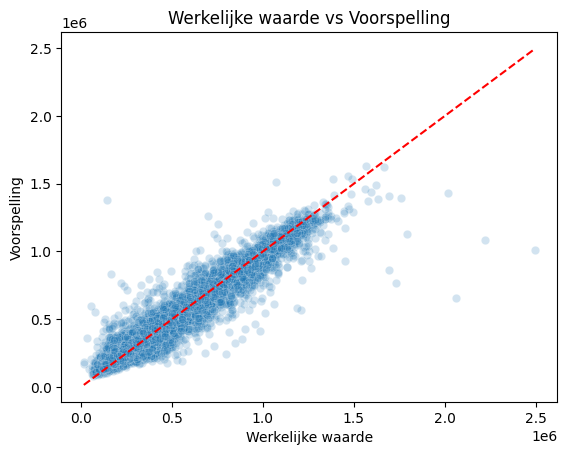

In [380]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x=y_test, y=y_pred, alpha=0.2)
plt.xlabel('Werkelijke waarde')
plt.ylabel('Voorspelling')
plt.title('Werkelijke waarde vs Voorspelling')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')  
plt.show()


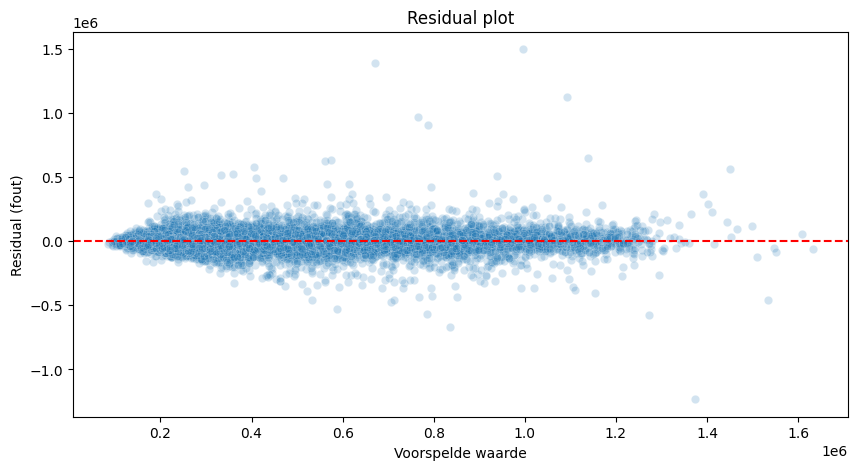

In [373]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.2) 
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Voorspelde waarde")
plt.ylabel("Residual (fout)")
plt.title("Residual plot")
plt.show()


Ik test het verschil tussen de r2 scores, wanneer ik predicties maak op de train data en op de test data. Zo zie ik het verschil wanneer ik mijn model test op de trainingsdata of op nieuwe data. Uit de output kan ik concluderen dat mijn model de trainingsdata goed van buiten kent, en ook redelijk hoog scoort op nieuwe data. Aangezien er geen groot verschil zit op de r2 van de nieuwe data(0.6), vermoed ik niet dat er overfitting is.

In [372]:
from sklearn.metrics import r2_score

y_train_pred = opgeslagen_rf.predict(X_train)
y_test_pred = opgeslagen_rf.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"R² train: {r2_train:.2f}")
print(f"R² test : {r2_test:.2f}")


R² train: 0.99
R² test : 0.93


Hier test ik met cross validatie op mijn model. Ik stel n_splits in op 5 bij KFold. De data wordt dus gesplit in 5 delen en per stuk wordt er een model getraind en getest. Per split print ik de MAPE en ook het gemiddelde van alle samen. Dit geeft mijn een betrouwbaarder beeld op hoe mijn model presteert. 

In [374]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_absolute_percentage_error

mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X, y, cv=kf, scoring=mape_scorer)

print(f"MAPE per fold: {-scores}")
print(f"Gemiddelde MAPE: {-scores.mean():.2f}")


MAPE per fold: [0.14201489 0.1405904  0.14087665 0.13893022 0.13800866]
Gemiddelde MAPE: 0.14


### feature importances checken

Ik check de belangrijkste features in mij model en steek deze in een df. Deze sorteer en print ik dan naar een csv zodat ik deze makkelijk kan bekijken. Hierin stonden wat lagere importances zoals enkele weerfeatures, maar ik besloot deze er in te laten. Er waren ook enkele zenders waarvan de importance 0 was. Aangezien deze one hot encoded zenders wel kunnen voorkomen in nieuwe data mag ik deze niet verwijderen, anders herkent mijn model deze input zender niet en kan dat voor onbetrouwbare predicties zorgen.

In [326]:
importances = rf.feature_importances_

feat_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

feat_importances = feat_importances.sort_values(by='Importance', ascending=False)

feat_importances.to_csv("feature_importances_rf.csv")

### GridsearchCV

Hier maak ik gebruik van GridsearchCV om voor verschillende parameters een model te trainen en te testen. Zo kan ik zine welke params het beste resultaat opleveren en kan ik mijn parameters tunen. Ik print de beste params en de enkele scores die ze opleveren. De score was verschilde niet veel, dus heb ik deze hyperparamaters niet toegepast op mijn werkelijke model.

In [376]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y = df_merged["Kijkers"]
X = df_merged.drop(columns=["Kijkers"])  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(random_state=42)


param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Beste hyperparameters: {grid_search.best_params_}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2-score: {r2:.3f}")


Beste hyperparameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
RMSE: 75918.88
MAE: 48662.16
R2-score: 0.925


### Andere modellen testen

Hieronder staan nog enkele andere modellen die ik getest heb, maar niets scoorde even goed als mijn random forest, dus ben ik hier niet verder op in gegaan.

In [25]:
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

y = df_merged["Kijkers"]
X = df_merged.drop(columns=["Kijkers"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "XGBoost Regressor": XGBRegressor(n_estimators=100, max_depth=3, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=100, random_state=42), 
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "ElasticNet": ElasticNet(max_iter=10000),  
    "AdaBoostRegressor": AdaBoostRegressor()
}

for name, model in models.items():
    if name in ["ElasticNet"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100  

    print(f"{name}")
    print(f" R²-score: {r2:.4f}")
    print(f" MAE     : {mae:.2f}")
    print(f" MAPE    : {mape:.2f}%")
    print("")


Linear Regression
 R²-score: 0.7435
 MAE     : 100287.83
 MAPE    : 30.84%

XGBoost Regressor
 R²-score: 0.8842
 MAE     : 63033.15
 MAPE    : 18.05%

Gradient Boosting Regressor
 R²-score: 0.8633
 MAE     : 68197.52
 MAPE    : 19.72%

Decision Tree Regressor
 R²-score: 0.8509
 MAE     : 67604.28
 MAPE    : 19.27%

ElasticNet
 R²-score: 0.6652
 MAE     : 114748.54
 MAPE    : 33.36%

AdaBoostRegressor
 R²-score: 0.6431
 MAE     : 135904.12
 MAPE    : 52.35%



Hier print ik ook eens voor de andere modellen een plot die de predicties en werkelijke waarden vergelijkt.

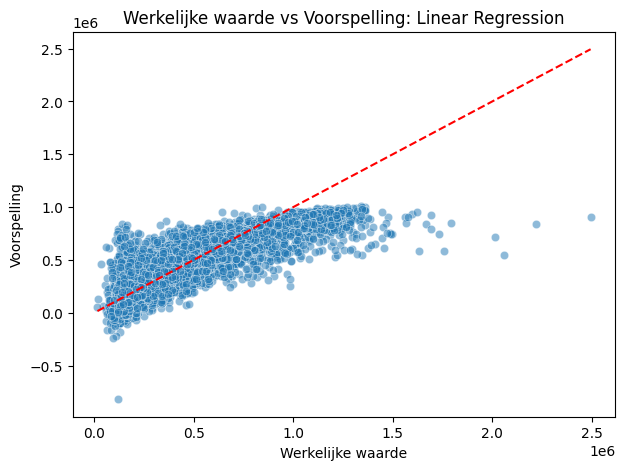

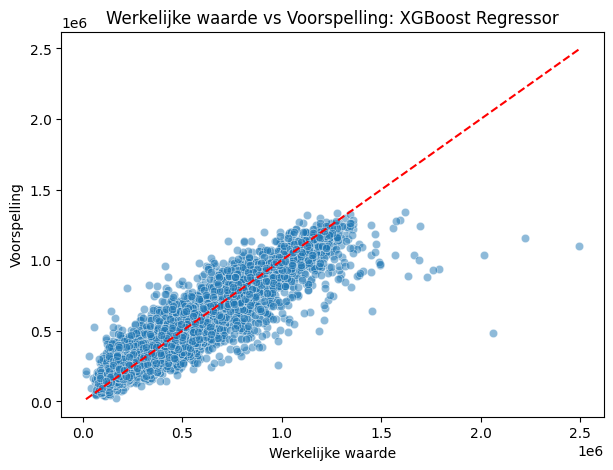

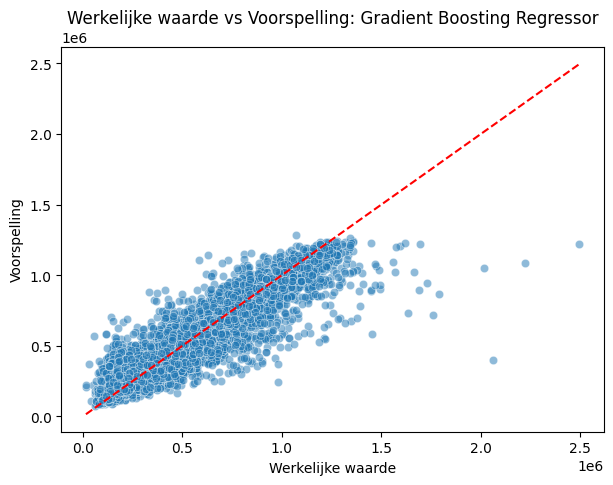

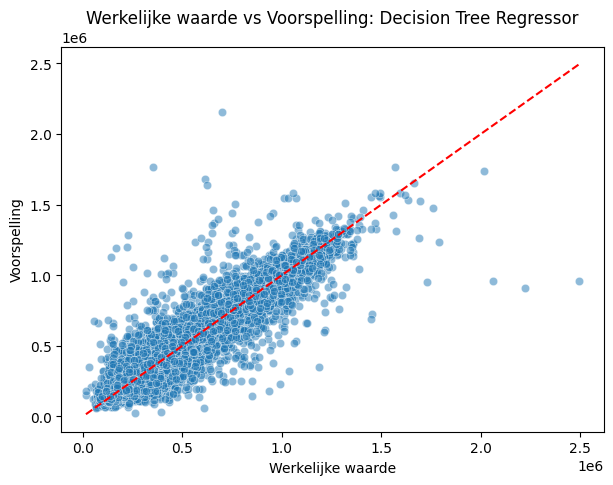

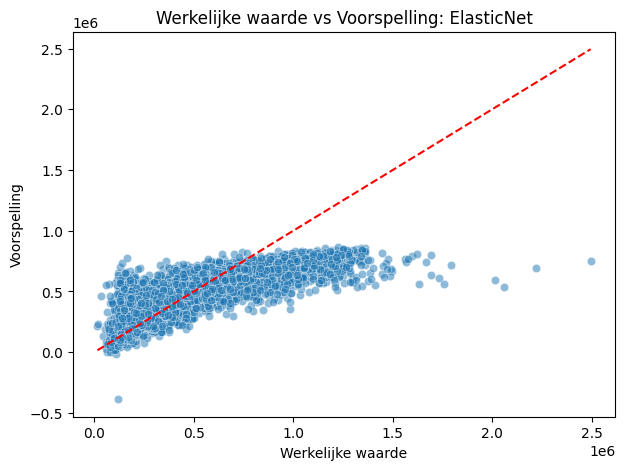

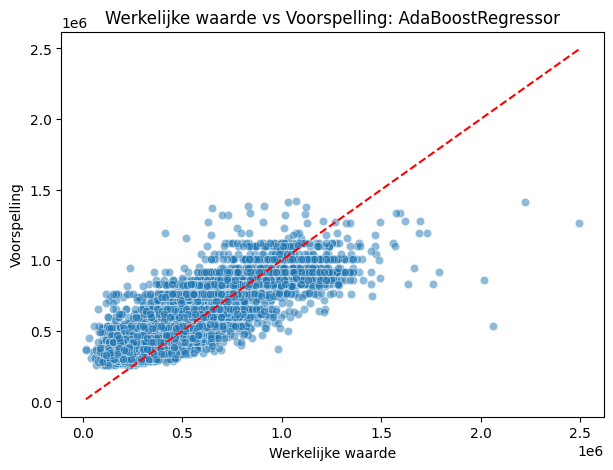

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

for name, model in models.items():
    if name == "ElasticNet":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    plt.figure(figsize=(7, 5))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    plt.xlabel('Werkelijke waarde')
    plt.ylabel('Voorspelling')
    plt.title(f'Werkelijke waarde vs Voorspelling: {name}')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.show()


Tenslotte heb ik nog eens geprobeer om een stacked ensemble te maken. Hier combineer ik random forest en xgboost met een lineair regressie als meta-model. De random_forest en xgboost worden apart getraind en dan wordt de output van beide doorgegeven aan lineair regressie model. Dit model leert dan van de voorspellingen van random forest en xgboost om nog betere voorspellingen te kunnen doen.

Ik test op het einde ook het model en het scoorde beter dan mijn random forest. Dit is het model dat ik uiteindelijk zal gebruiken op het examen.

In [388]:
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

y = df_merged["Kijkers"]
X = df_merged.drop(columns=["Kijkers"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

base_models = [
    ("random_forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("xgboost", XGBRegressor(n_estimators=100, random_state=42))
]

stacked_model = StackingRegressor(estimators=base_models, final_estimator=LinearRegression())

stacked_model.fit(X_train, y_train)
y_pred = stacked_model.predict(X_test)

print("Stacked Model (Random Forest + XGBoost):")
print(f" R²-score: {r2_score(y_test, y_pred):.4f}")
print(f" MAE     : {mean_absolute_error(y_test, y_pred):.2f}")
print(f" MAPE    : {mean_absolute_percentage_error(y_test, y_pred) * 100:.2f}%")

joblib.dump(stacked_model, "stacked_model.pkl")


Stacked Model (Random Forest + XGBoost):
 R²-score: 0.9299
 MAE     : 47435.07
 MAPE    : 13.63%


['stacked_model.pkl']

Hieronder de predicties naast de werkelijke waarden voor mijn stacked model

In [33]:
import joblib  
import pandas as pd

stacked_model = joblib.load('stacked_model.pkl')
y_pred = stacked_model.predict(X_test)

results_df = pd.DataFrame({
    'Werkelijke waarde': y_test,
    'Voorspelling': np.round(y_pred, 1)
})

print(results_df.head(10))  


       Werkelijke waarde  Voorspelling
46375             517564      529338.0
28679             803857      848534.6
34639             899351      867098.5
48769             842897      883233.3
16332             283640      329552.8
50117             345627      302258.8
43213             328331      341580.0
18126             452177      488138.0
22976             195998      253575.8
7117              184970      206242.6


Zoals je kan zien zit mijn random forest er minder dicht bij dan mijn stacked model met xgboost

In [32]:
import joblib  
import pandas as pd

stacked_model = joblib.load('random_forest_model_v2.pkl')
y_pred = stacked_model.predict(X_test)

results_df = pd.DataFrame({
    'Werkelijke waarde': y_test,
    'Voorspelling': np.round(y_pred, 1)
})

print(results_df.head(10))  


       Werkelijke waarde  Voorspelling
46375             517564      560525.6
28679             803857      852263.8
34639             899351      864002.1
48769             842897      839713.3
16332             283640      325390.5
50117             345627      285579.1
43213             328331      356977.8
18126             452177      476182.1
22976             195998      263960.0
7117              184970      211559.4


Ik plot ook nog eens beide mooi naast elkaar. 

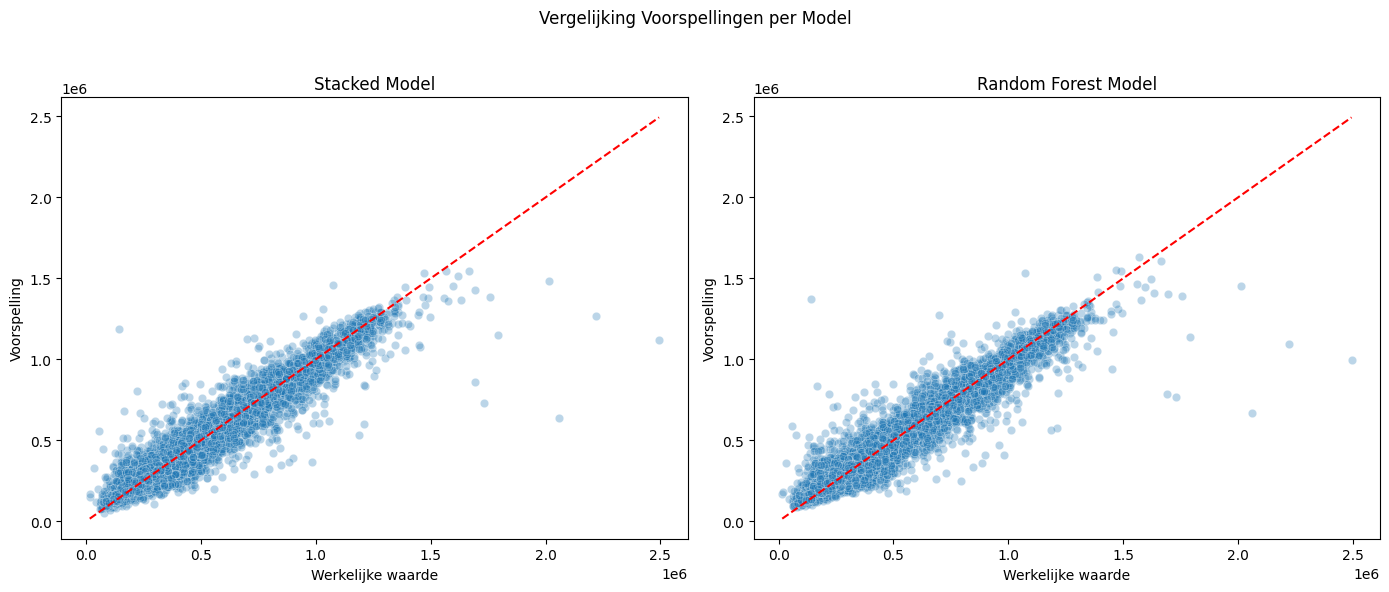

In [39]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

stacked_model = joblib.load('stacked_model.pkl')
rf_model = joblib.load('random_forest_model_v2.pkl')

y_pred_stacked = stacked_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=y_test, y=y_pred_stacked, alpha=0.3, ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') 
axes[0].set_title('Stacked Model')
axes[0].set_xlabel('Werkelijke waarde')
axes[0].set_ylabel('Voorspelling')

sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.3, ax=axes[1])
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') 
axes[1].set_title('Random Forest Model')
axes[1].set_xlabel('Werkelijke waarde')
axes[1].set_ylabel('Voorspelling')

plt.suptitle('Vergelijking Voorspellingen per Model')
plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.show()

